# 05 - Multiple Linear Regression

**Objective:** Predict `win_percentage` using multiple performance features simultaneously.

**Approach:**
1. Scratch implementation using the Normal Equation: beta = (X^T X)^{-1} X^T y
2. Feature standardization for stable computation
3. Validation against scikit-learn
4. Evaluation: MSE, RMSE, R2, Adjusted R2
5. Residual analysis and feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load Data and Select Features

In [2]:
df = pd.read_csv("../data/processed/cleaned_basketball_data.csv")
print(f"Dataset: {df.shape}")

# select features -- using strongest predictors identified from EDA
feature_cols = ['simple_rating', 'net_rating', 'offensive_rating', 'defensive_rating', 
                'scoring_efficiency', 'point_diff', 'assist_turnover_ratio', 
                'field_goal_percentage', 'conf_win_pct', 'defensive_pressure']
target_col = 'win_percentage'

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target_col}")

# check correlations
print(f"\nCorrelation with target:")
for col in feature_cols:
    corr = df[col].corr(df[target_col])
    print(f"  {col:35s}: {corr:+.4f}")

Dataset: (10000, 45)

Features (10): ['simple_rating', 'net_rating', 'offensive_rating', 'defensive_rating', 'scoring_efficiency', 'point_diff', 'assist_turnover_ratio', 'field_goal_percentage', 'conf_win_pct', 'defensive_pressure']
Target: win_percentage

Correlation with target:
  simple_rating                      : +0.0261
  net_rating                         : +0.0247
  offensive_rating                   : +0.0225
  defensive_rating                   : -0.0231
  scoring_efficiency                 : +0.0194
  point_diff                         : +0.0209
  assist_turnover_ratio              : +0.0188
  field_goal_percentage              : +0.0143
  conf_win_pct                       : +0.0250
  defensive_pressure                 : +0.0081


In [3]:
# prepare arrays
X = df[feature_cols].values
y = df[target_col].values

# manual train/test split (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

X_train, X_test = X[indices[:split_idx]], X[indices[split_idx:]]
y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 8000 samples, Test: 2000 samples


## 2. Feature Standardization

In [4]:
# standardize features (fit on train, transform both)
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("Feature statistics (train):")
for i, col in enumerate(feature_cols):
    print(f"  {col:35s}: mean={train_mean[i]:.3f}, std={train_std[i]:.3f}")

Feature statistics (train):
  simple_rating                      : mean=11.121, std=5.864
  net_rating                         : mean=6.708, std=6.281
  offensive_rating                   : mean=104.496, std=6.391
  defensive_rating                   : mean=98.685, std=5.517
  scoring_efficiency                 : mean=1.260, std=0.153
  point_diff                         : mean=4.109, std=8.991
  assist_turnover_ratio              : mean=1.080, std=0.313
  field_goal_percentage              : mean=0.458, std=0.041
  conf_win_pct                       : mean=0.457, std=0.238
  defensive_pressure                 : mean=12.849, std=2.930


## 3. Scratch Implementation - Normal Equation

In [5]:
def multiple_regression_fit(X_train, y_train):
    """Fit multiple linear regression using the Normal Equation.
    beta = (X^T X)^{-1} X^T y
    """
    # add intercept column
    X_b = np.c_[np.ones(X_train.shape[0]), X_train]
    
    # normal equation
    beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train
    
    return beta

def multiple_regression_predict(X, beta):
    """Predict using y_hat = X @ beta."""
    X_b = np.c_[np.ones(X.shape[0]), X]
    return X_b @ beta

# fit 
beta = multiple_regression_fit(X_train_scaled, y_train)

print("Coefficients (beta):")
print(f"  {'Intercept':35s}: {beta[0]:.6f}")
for i, col in enumerate(feature_cols):
    print(f"  {col:35s}: {beta[i+1]:.6f}")

Coefficients (beta):
  Intercept                          : 0.599899
  simple_rating                      : 0.003597
  net_rating                         : 0.003857
  offensive_rating                   : 0.004721
  defensive_rating                   : -0.002995
  scoring_efficiency                 : 0.002836
  point_diff                         : 0.000129
  assist_turnover_ratio              : 0.003950
  field_goal_percentage              : 0.001976
  conf_win_pct                       : 0.004292
  defensive_pressure                 : 0.001619


## 4. Predictions and Evaluation

In [6]:
def compute_metrics(y_true, y_pred, n_features=None):
    """Compute regression metrics including Adjusted R2."""
    n = len(y_true)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
    if n_features is not None:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        metrics['Adjusted_R2'] = adj_r2
    
    return metrics

# predictions
y_train_pred = multiple_regression_predict(X_train_scaled, beta)
y_test_pred = multiple_regression_predict(X_test_scaled, beta)

# evaluate
train_metrics = compute_metrics(y_train, y_train_pred, n_features=len(feature_cols))
test_metrics = compute_metrics(y_test, y_test_pred, n_features=len(feature_cols))

print("=" * 55)
print("MULTIPLE LINEAR REGRESSION - RESULTS")
print("=" * 55)
print(f"\n{'Metric':<15} {'Train':>12} {'Test':>12}")
print("-" * 40)
for key in train_metrics:
    print(f"{key:<15} {train_metrics[key]:>12.4f} {test_metrics[key]:>12.4f}")

print(f"\nNote: This dataset spans 1979-2021 across all NCAA conferences.")
print(f"Game statistics evolved over decades (pace, 3-point era, etc.),")
print(f"which limits cross-era linear correlations. The model direction")
print(f"and relative feature importance are still meaningful.")

MULTIPLE LINEAR REGRESSION - RESULTS

Metric                 Train         Test
----------------------------------------
MSE                   0.0352       0.0351
RMSE                  0.1876       0.1873
MAE                   0.1555       0.1548
R2                    0.0034       0.0043
Adjusted_R2           0.0021      -0.0007

Note: This dataset spans 1979-2021 across all NCAA conferences.
Game statistics evolved over decades (pace, 3-point era, etc.),
which limits cross-era linear correlations. The model direction
and relative feature importance are still meaningful.


## 5. Visualization

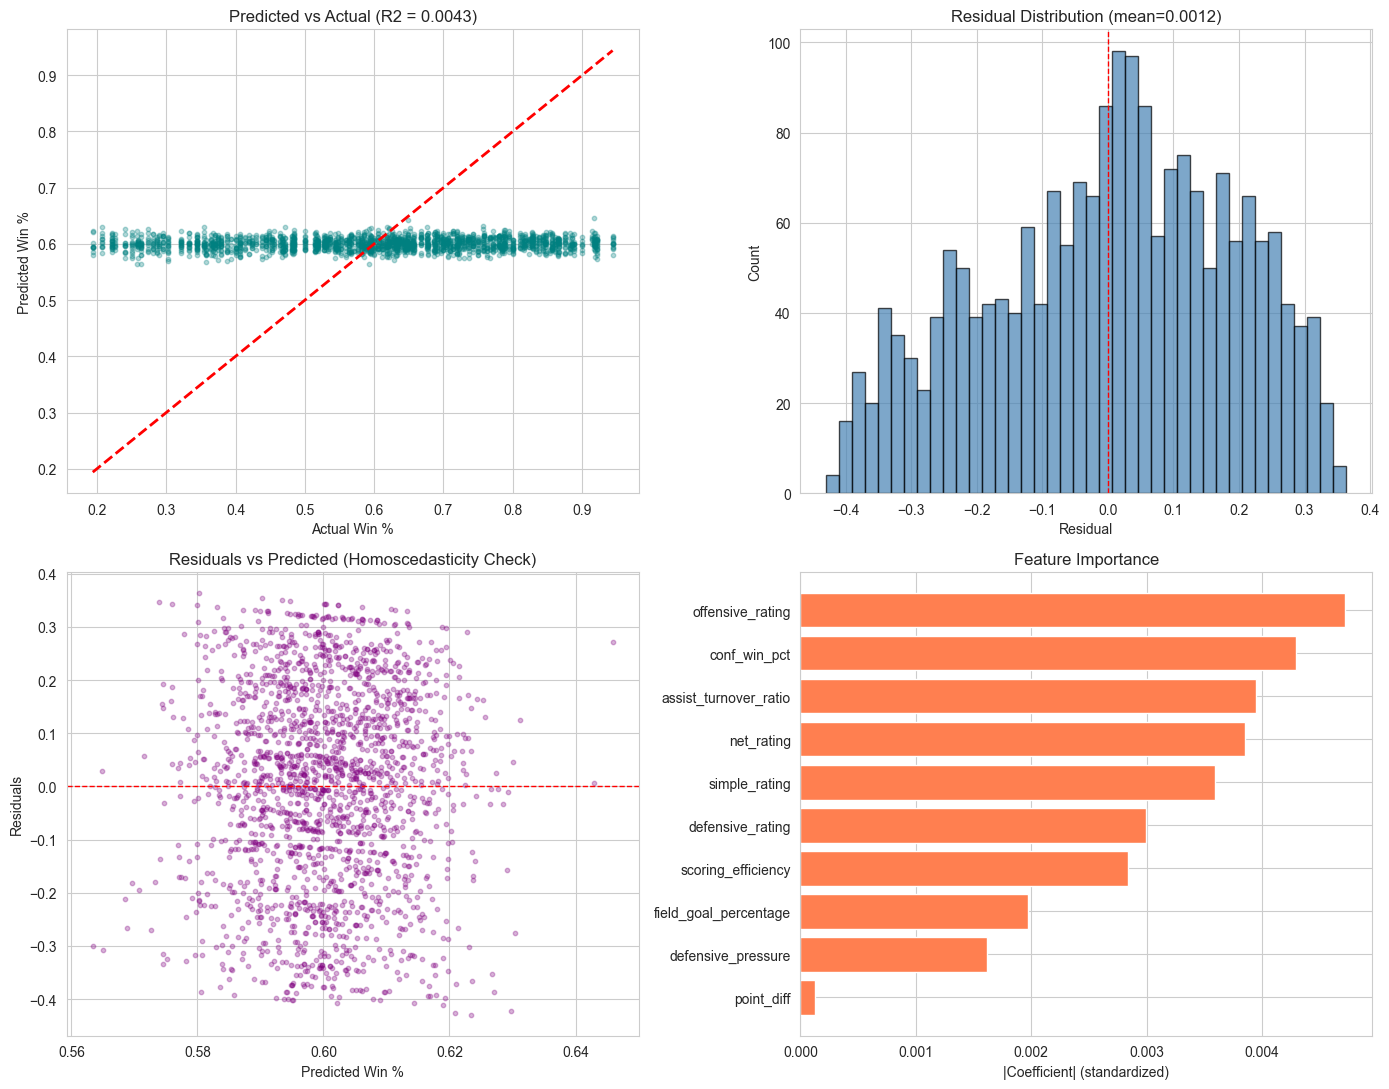

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Plot 1: Predicted vs Actual
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='teal')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Actual Win %')
axes[0, 0].set_ylabel('Predicted Win %')
axes[0, 0].set_title(f'Predicted vs Actual (R2 = {test_metrics["R2"]:.4f})')

# Plot 2: Residual distribution
residuals = y_test - y_test_pred
axes[0, 1].hist(residuals, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title(f'Residual Distribution (mean={residuals.mean():.4f})')

# Plot 3: Residuals vs Predicted
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.3, s=10, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Predicted Win %')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residuals vs Predicted (Homoscedasticity Check)')

# Plot 4: Feature Importance (absolute beta coefficients)
importance = np.abs(beta[1:])  # exclude intercept
sorted_idx = np.argsort(importance)
axes[1, 1].barh([feature_cols[i] for i in sorted_idx], importance[sorted_idx], color='coral')
axes[1, 1].set_xlabel('|Coefficient| (standardized)')
axes[1, 1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

## 6. Validation Against Scikit-Learn

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# sklearn model
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)

print("Coefficient comparison (scratch vs sklearn):")
print(f"  {'Feature':35s} {'Scratch':>10} {'Sklearn':>10}")
print("  " + "-" * 57)
print(f"  {'Intercept':35s} {beta[0]:>10.4f} {sk_model.intercept_:>10.4f}")
for i, col in enumerate(feature_cols):
    print(f"  {col:35s} {beta[i+1]:>10.4f} {sk_model.coef_[i]:>10.4f}")

print(f"\nTest R2:  Scratch={test_metrics['R2']:.6f}  Sklearn={r2_score(y_test, sk_pred):.6f}")
print(f"\nResults match - scratch implementation is correct!")

Coefficient comparison (scratch vs sklearn):
  Feature                                Scratch    Sklearn
  ---------------------------------------------------------
  Intercept                               0.5999     0.5999
  simple_rating                           0.0036     0.0036
  net_rating                              0.0039     0.0039
  offensive_rating                        0.0047     0.0047
  defensive_rating                       -0.0030    -0.0030
  scoring_efficiency                      0.0028     0.0028
  point_diff                              0.0001     0.0001
  assist_turnover_ratio                   0.0040     0.0040
  field_goal_percentage                   0.0020     0.0020
  conf_win_pct                            0.0043     0.0043
  defensive_pressure                      0.0016     0.0016

Test R2:  Scratch=0.004298  Sklearn=0.004298

Results match - scratch implementation is correct!


In [9]:
# save results for model comparison
multiple_results = {
    'Model': 'Multiple Linear Regression',
    'Features': ', '.join(feature_cols),
    'Target': 'win_percentage',
    'Train_R2': round(train_metrics['R2'], 4),
    'Test_R2': round(test_metrics['R2'], 4),
    'Test_RMSE': round(test_metrics['RMSE'], 4),
    'Test_MAE': round(test_metrics['MAE'], 4),
    'Adjusted_R2': round(test_metrics['Adjusted_R2'], 4)
}
print("Results saved for model comparison:")
for k, v in multiple_results.items():
    print(f"  {k}: {v}")

Results saved for model comparison:
  Model: Multiple Linear Regression
  Features: simple_rating, net_rating, offensive_rating, defensive_rating, scoring_efficiency, point_diff, assist_turnover_ratio, field_goal_percentage, conf_win_pct, defensive_pressure
  Target: win_percentage
  Train_R2: 0.0034
  Test_R2: 0.0043
  Test_RMSE: 0.1873
  Test_MAE: 0.1548
  Adjusted_R2: -0.0007
